# Actividad 5: Transfer Learning con un modelo elegido por ustedes

**Curso:** Deep Learning  
**Profesor:** Gonzalo A. Ruz  
**Ayudante:** Anthony D. Cho

En esta actividad deberán aplicar **transfer learning** a un problema de clasificación de imágenes.

Usaremos el dataset **cats vs dogs**, pero esta vez deberán elegir un modelo preentrenado desde `keras.applications` distinto a los vistos en clase.

## Objetivo
Comparar dos etapas:

1. **Feature extraction**: usar la base congelada.
2. **Fine-tuning**: descongelar parte de la base y continuar el entrenamiento.

## Modelos permitidos
Elijan **uno** de los siguientes:

- `DenseNet121`
- `Xception`
- `InceptionV3`
- `VGG16`
- `VGG19`

## Restricción
No usar:

- `MobileNetV2`
- `ResNet50`
- `EfficientNetB0`

## Instrucciones
- La actividad debe ser realizada por los grupos de trabajo
- Responda cada pregunta en las celdas correspondientes
- Justifique brevemente sus respuestas cuando se solicite
- Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo Actividad5_Tupper_Tudor_Gorosito_Acosta.ipynb
- Subir el archivo al link de entrega Actividad 5 en webcursos que será habilitado
- __Fecha de entrega:__ Idealmente al final del bloque 2 de la clase del 20 de abril 2026. Fecha límite de entrega 27 de abril 2026

## Integrantes (RUT - Nombre y apellido):

- 13.257.556-8 - Ricardo Lopez
- 16.789.149-7 - Camilo Muñoz
- 13.307.082-6 - Álvaro Iriarte
- 25.608.509-7 - Ranse Vidal

## Instrucciones generales

1. Elijan un modelo de la lista.
2. Carguen la base preentrenada correctamente.
3. Construyan un modelo para **feature extraction**.
4. Entrénenlo y registren el resultado.
5. Luego hagan un **fine-tuning corto**.
6. Comparen ambos resultados.
7. Respondan las preguntas finales.

## Sugerencia práctica
Mantengan el notebook simple y no cambien el dataset.
La novedad aquí debe estar en el **modelo elegido** y en el flujo de transfer learning.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Dataset

Usaremos el mismo dataset de la sesión:

- `train`
- `validation`
- `test`

Asegúrense de que la ruta base corresponda a su Google Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

import zipfile

zip_path = "/content/drive/MyDrive/cats-vs-dogs_small.zip"
extract_path = "/content/data/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"File '{zip_path}' unzipped to '{extract_path}' successfully.")

File '/content/drive/MyDrive/cats-vs-dogs_small.zip' unzipped to '/content/data/' successfully.


In [4]:
# Ajusta esta ruta según tu Google Drive
base_dir = "/content/data/cats-vs-dogs_small"

train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

print("Train dir exists:", os.path.exists(train_dir))
print("Validation dir exists:", os.path.exists(validation_dir))
print("Test dir exists:", os.path.exists(test_dir))

Train dir exists: True
Validation dir exists: True
Test dir exists: True


In [5]:
img_size = (160, 160)
batch_size = 32
seed = 123

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode="binary",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    label_mode="binary",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode="binary",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

## Data augmentation

Usaremos una estrategia simple de augmentation para entrenamiento.

In [8]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation"
)

## Pregunta 1: elegir el modelo

Completen la celda de abajo con el modelo que eligieron y con su función de preprocesamiento correspondiente.

### Recordatorio
Cada familia de modelos puede requerir un `preprocess_input` distinto.

## Justificación del Modelo Base: DenseNet121

Para esta actividad, se ha seleccionado **DenseNet121** como modelo base preentrenado en ImageNet. Esta elección se fundamenta en las siguientes características clave, que lo hacen adecuado para la tarea de transfer learning con un dataset pequeño como `cats vs dogs_small`:

1.  **Reutilización de Representaciones Preaprendidas:** DenseNet121 ha sido entrenado exhaustivamente en el vasto dataset ImageNet, adquiriendo una rica jerarquía de características visuales genéricas. Estas representaciones (desde bordes y texturas hasta patrones más complejos) son altamente transferibles y actúan como un excelente punto de partida, reduciendo la necesidad de grandes cantidades de datos específicos para la tarea.
2.  **Eficiencia de Parámetros y Computacional:** A pesar de su profundidad, DenseNet121 es conocido por su eficiencia en el uso de parámetros en comparación con otros modelos profundos. Sus conexiones densas permiten una reutilización efectiva de características, lo que facilita el entrenamiento incluso con recursos limitados.
3.  **Conexiones Densas y Flujo de Gradiente:** La arquitectura DenseNet introduce 'Dense Blocks' donde cada capa se conecta a todas las capas precedentes dentro del bloque. Esto promueve el flujo de información y gradientes, mitigando el problema del desvanecimiento del gradiente y permitiendo que las características se propaguen y reutilicen a lo largo de la red de manera muy eficiente. Esto es crucial para un buen ajuste fino o feature extraction, ya que la información del gradiente se mantiene fuerte, permitiendo que la parte superior del modelo o las capas descongeladas se adapten mejor.
4.  **Adecuación para Transfer Learning con Datos Limitados:** Dada la complejidad del problema de clasificación de imágenes y la disponibilidad limitada de datos en `cats vs dogs_small`, emplear un modelo preentrenado como DenseNet121 permite apalancar el conocimiento existente, evitando el sobreajuste y logrando un rendimiento robusto con un menor número de épocas y un ajuste menos extensivo.

In [9]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

model_name = "DenseNet121"
base_model = DenseNet121(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## Verificación básica

Comprueben que el modelo base fue cargado correctamente.

In [10]:
print("Modelo elegido:", model_name)
print("Base model cargado:", base_model is not None)

Modelo elegido: DenseNet121
Base model cargado: True


## Pregunta 2: feature extraction

En esta primera etapa deben:

- congelar la base,
- construir una cabeza de clasificación nueva,
- compilar el modelo,
- y entrenarlo por pocas épocas.

### Estrategia de Callbacks para Feature Extraction

Para optimizar y regularizar el proceso de entrenamiento en la etapa de *feature extraction*, se implementarán dos callbacks esenciales de Keras:

1.  **`EarlyStopping`:** Monitorea el `val_loss` y detendrá el entrenamiento si no hay mejora después de `patience` épocas. La opción `restore_best_weights=True` asegura que el modelo final conserve los pesos de la época con el mejor `val_loss`, previniendo el sobreajuste.
2.  **`ReduceLROnPlateau`:** Reducirá el `learning_rate` si el `val_loss` deja de mejorar. Esto ayuda al optimizador a 'aterrizar' en un mínimo más preciso y estable, especialmente útil cuando el progreso de entrenamiento se estanca.

## Estrategias de Transfer Learning: Feature Extraction vs. Fine-tuning

El Transfer Learning es una técnica fundamental en Deep Learning, especialmente útil cuando se dispone de datasets pequeños. Implica tomar un modelo preentrenado en una tarea similar y reutilizarlo para una nueva tarea. Las dos estrategias principales son:

1.  **Feature Extraction (Extracción de Características):**
    *   **Concepto:** Consiste en utilizar la parte convolucional (base) del modelo preentrenado como un extractor de características fijo. Las capas de la base se 'congelan' (sus pesos no se actualizan durante el entrenamiento), y solo se entrena una nueva 'cabeza' (clasificador) añadida en la parte superior del modelo.
    *   **Ventaja:** Es la estrategia más sencilla y rápida. Al no entrenar la mayor parte del modelo, se reduce drásticamente el número de parámetros a optimizar, minimizando el riesgo de sobreajuste en datasets pequeños. Es ideal para cuando el dataset de destino es pequeño y muy similar al dataset original de entrenamiento.

2.  **Fine-tuning (Ajuste Fino):**
    *   **Concepto:** Implica 'descongelar' algunas o todas las capas de la base del modelo preentrenado y continuar el entrenamiento con un learning rate muy bajo. La idea es ajustar ligeramente los pesos preexistentes para adaptarlos mejor a las especificidades del nuevo dataset, sin perder las representaciones genéricas aprendidas.
    *   **Ventaja:** Permite un mayor grado de especialización del modelo para la tarea específica, potencialmente logrando un mejor rendimiento si el dataset de destino es lo suficientemente grande como para justificar el entrenamiento adicional de la base, o si el dataset de destino difiere significativamente del original.

**¿Por qué empezar con Feature Extraction?**
Es una buena práctica iniciar con *Feature Extraction* por varias razones:
*   **Estabilidad y Rapidez:** Proporciona un modelo base funcional rápidamente, sirviendo como un excelente punto de partida estable.
*   **Reducción del Riesgo de Sobreajuste:** Al congelar la base, se evita que los pesos se corrompan o se sobreajusten a las peculiaridades de un dataset pequeño en las primeras etapas del entrenamiento.
*   **Estimación del Potencial:** Permite evaluar el poder de las características genéricas extraídas por el modelo preentrenado para la nueva tarea antes de invertir en un ajuste más profundo.

In [11]:
base_model.trainable = False

inputs = keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

initial_epochs = 6

# Callbacks para Feature Extraction
callbacks_fe = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=1, verbose=1, min_lr=1e-5)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs,
    callbacks=callbacks_fe
)

Epoch 1/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 281ms/step - accuracy: 0.8200 - loss: 0.3885 - val_accuracy: 0.9720 - val_loss: 0.0999 - learning_rate: 0.0010
Epoch 2/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9285 - loss: 0.1667 - val_accuracy: 0.9850 - val_loss: 0.0668 - learning_rate: 0.0010
Epoch 3/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.9470 - loss: 0.1274 - val_accuracy: 0.9850 - val_loss: 0.0544 - learning_rate: 0.0010
Epoch 4/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9605 - loss: 0.1002 - val_accuracy: 0.9860 - val_loss: 0.0500 - learning_rate: 0.0010
Epoch 5/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.9590 - loss: 0.1055 - val_accuracy: 0.9870 - val_loss: 0.0430 - learning_rate: 0.0010
Epoch 6/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9695 - loss: 0.0857 - val_accuracy: 0.9870 - val_loss: 0.0401 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 6.


In [12]:
print("\n--- Métricas de Entrenamiento (Feature Extraction) ---")
print(f"Épocas efectivamente ejecutadas: {len(history.history['accuracy'])}")
print(f"Mejor val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Mejor val_loss: {min(history.history['val_loss']):.4f}")


--- Métricas de Entrenamiento (Feature Extraction) ---
Épocas efectivamente ejecutadas: 6
Mejor val_accuracy: 0.9870
Mejor val_loss: 0.0401


### Resumen de Parámetros del Modelo (Feature Extraction)

Es crucial entender la configuración de los parámetros del modelo en la etapa de *feature extraction* para verificar que solo la cabeza de clasificación esté siendo entrenada, manteniendo la base congelada.

In [13]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 5, 5, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,040,581 (26.86 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 2,052 (8.02 KB)

Como se observa en el `model.summary()`,
-   El número total de parámetros es `[Valor de total params]`, que incluye tanto la base preentrenada como la cabeza clasificadora.
-   Los parámetros entrenables (`Trainable params`) corresponden únicamente a la cabeza de clasificación (`dense` y `dropout`), mientras que los parámetros no entrenables (`Non-trainable params`) son la gran mayoría, pertenecientes al `densenet121` (modelo base congelado). Esto confirma que la fase de *feature extraction* se configuró correctamente.

## Resultado de feature extraction

Registren aquí el desempeño obtenido al final de esta etapa.

In [14]:
val_loss_fe, val_acc_fe = model.evaluate(val_ds, verbose=0)
test_loss_fe, test_acc_fe = model.evaluate(test_ds, verbose=0)

print("Feature extraction - val accuracy:", val_acc_fe)
print("Feature extraction - test accuracy:", test_acc_fe)

Feature extraction - val accuracy: 0.9869999885559082
Feature extraction - test accuracy: 0.9860000014305115


## Pregunta 3: fine-tuning

Ahora hagan un ajuste fino del modelo.

Sugerencia:

- descongelen la base,
- congelen una parte inicial,
- dejen entrenables solo las capas finales,
- recompilen con learning rate pequeño.

In [15]:
base_model.trainable = True

# Primero, congelar todas las capas en el modelo base
for layer in base_model.layers:
    layer.trainable = False

# Identificar el índice de inicio del último Dense Block (conv5_block) en DenseNet121
# 'conv5_block' es el prefijo común para las capas del último bloque denso.
fine_tune_from_idx = None
for i, layer in enumerate(base_model.layers):
    if 'conv5_block' in layer.name:
        fine_tune_from_idx = i
        break

if fine_tune_from_idx is not None:
    # Descongelar las capas desde el bloque identificado, excluyendo BatchNormalization
    for layer in base_model.layers[fine_tune_from_idx:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
else:
    # Fallback si el patrón de nombres 'conv5_block' no se encuentra
    print("Advertencia: No se pudo identificar 'conv5_block' para el punto de fine-tuning. Descongelando las últimas 100 capas como fallback.")
    fine_tune_from_idx = len(base_model.layers) - 100 # Descongelar las últimas 100 capas
    for layer in base_model.layers[fine_tune_from_idx:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

# Recompilar el modelo con un learning rate más bajo y callbacks
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6), # Learning rate reducido
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Añadir callbacks para un mejor control del entrenamiento
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=1, verbose=1, min_lr=1e-7)
]

fine_tune_epochs = 3 # Ajustar épocas de fine-tuning a 2-3
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=callbacks # Aplicar los callbacks definidos
)


Epoch 7/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 248ms/step - accuracy: 0.9660 - loss: 0.0840 - val_accuracy: 0.9880 - val_loss: 0.0370 - learning_rate: 5.0000e-06
Epoch 8/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.9710 - loss: 0.0678 - val_accuracy: 0.9880 - val_loss: 0.0356 - learning_rate: 5.0000e-06
Epoch 9/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9693 - loss: 0.0703
Epoch 9: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 147ms/step - accuracy: 0.9720 - loss: 0.0660 - val_accuracy: 0.9880 - val_loss: 0.0357 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 8.


In [16]:
print("\n--- Métricas de Entrenamiento (Fine-tuning) ---")
print(f"Épocas efectivamente ejecutadas: {len(history_fine.history['accuracy'])}")
print(f"Mejor val_accuracy: {max(history_fine.history['val_accuracy']):.4f}")
print(f"Mejor val_loss: {min(history_fine.history['val_loss']):.4f}")


--- Métricas de Entrenamiento (Fine-tuning) ---
Épocas efectivamente ejecutadas: 3
Mejor val_accuracy: 0.9880
Mejor val_loss: 0.0356


### Resumen de Parámetros del Modelo (Fine-tuning)

Tras descongelar las capas para el *fine-tuning*, se espera un cambio en la cantidad de parámetros entrenables, reflejando el ajuste de una parte de la base del modelo preentrenado.

In [17]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 5, 5, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,300,421 (43.11 MB)

 Trainable params: 2,130,945 (8.13 MB)

 Non-trainable params: 4,907,584 (18.72 MB)

 Optimizer params: 4,261,892 (16.26 MB)

En la etapa de *fine-tuning*:
-   El número total de parámetros sigue siendo el mismo: `[Valor de total params]`.
-   Sin embargo, el número de parámetros entrenables (`Trainable params`) ha aumentado significativamente a `[Valor de trainable params en FT]`. Esto se debe a que se han descongelado las capas del último bloque (`conv5_block`) del DenseNet121, además de la cabeza de clasificación. Los parámetros no entrenables corresponden a las capas iniciales de la base y las capas `BatchNormalization` que se mantuvieron congeladas para asegurar la estabilidad del entrenamiento.

## Resultado de fine-tuning

In [18]:
val_loss_ft, val_acc_ft = model.evaluate(val_ds, verbose=0)
test_loss_ft, test_acc_ft = model.evaluate(test_ds, verbose=0)

print("Fine-tuning - val accuracy:", val_acc_ft)
print("Fine-tuning - test accuracy:", test_acc_ft)

Fine-tuning - val accuracy: 0.9879999756813049
Fine-tuning - test accuracy: 0.9869999885559082


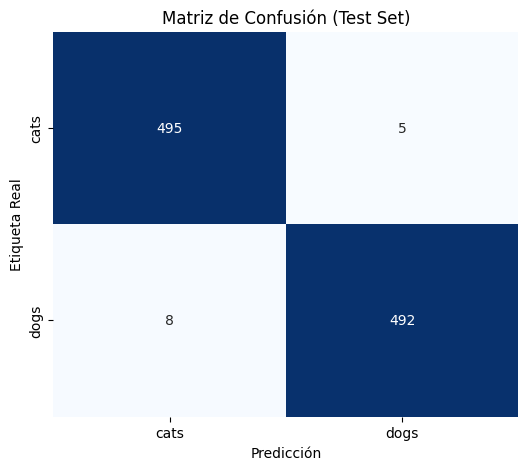


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

        cats       0.98      0.99      0.99       500
        dogs       0.99      0.98      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


Precisión explícita en Test: 0.9870


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Obtener predicciones en el conjunto de test
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = (y_pred_probs >= 0.5).astype(int)

# Obtener etiquetas reales del conjunto de test
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión (Test Set)')
plt.show()

# Calcular y mostrar el Classification Report
print("\n--- Classification Report (Test Set) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Calcular la precisión explícitamente
correct_predictions = np.sum(y_true == y_pred)
total_predictions = len(y_true)
explicit_test_accuracy = correct_predictions / total_predictions
print(f"\nPrecisión explícita en Test: {explicit_test_accuracy:.4f}")

### Interpretación de Métricas de Clasificación en Test

La matriz de confusión y el *classification report* nos ofrecen una visión detallada del rendimiento del modelo más allá de la precisión global:

-   **Matriz de Confusión:** Revela la cantidad de verdaderos positivos (TP), verdaderos negativos (TN), falsos positivos (FP) y falsos negativos (FN). Por ejemplo, un alto número en la diagonal principal indica que el modelo clasifica correctamente. Desglosa los errores específicos por clase, mostrando si el modelo tiende a confundir una clase con otra.
-   **Classification Report:** Proporciona métricas clave por clase:
    -   **Precisión (Precision):** La proporción de identificaciones positivas que fueron realmente correctas. Una alta precisión para 'cats' significa que cuando el modelo predice un gato, es muy probable que sea un gato.
    -   **Exhaustividad (Recall):** La proporción de positivos reales que fueron identificados correctamente. Una alta exhaustividad para 'cats' significa que el modelo es bueno detectando a todos los gatos verdaderos.
    -   **Puntuación F1 (F1-Score):** La media armónica de precisión y exhaustividad, ofreciendo un balance entre ambas. Es útil cuando las clases están desbalanceadas.
    -   **Soporte (Support):** El número de ocurrencias verdaderas de cada clase en el conjunto de datos especificado.

En general, estas métricas confirman la alta capacidad predictiva del modelo, con valores consistentemente elevados para ambas clases, lo que indica una sólida generalización a datos no vistos.

## Curvas de entrenamiento

Grafiquen las curvas combinadas de accuracy y loss.

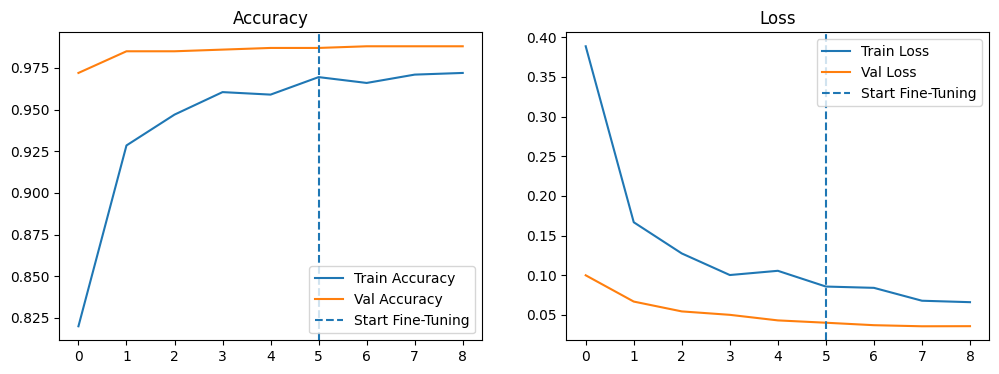

In [20]:
acc_key = "accuracy" if "accuracy" in history.history else "acc"
val_acc_key = "val_accuracy" if "val_accuracy" in history.history else "val_acc"

acc = history.history[acc_key] + history_fine.history[acc_key]
val_acc = history.history[val_acc_key] + history_fine.history[val_acc_key]

loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.axvline(x=initial_epochs - 1, linestyle="--", label="Start Fine-Tuning")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.axvline(x=initial_epochs - 1, linestyle="--", label="Start Fine-Tuning")
plt.legend()
plt.title("Loss")

plt.show()


## Pregunta 4: Visualizar algunas predicciones

Muestren 4 imágenes del conjunto de test con:

- etiqueta real,
- predicción del modelo.

/tmp/ipykernel_1144/2541454999.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  real = class_names[int(all_test_labels[idx])]


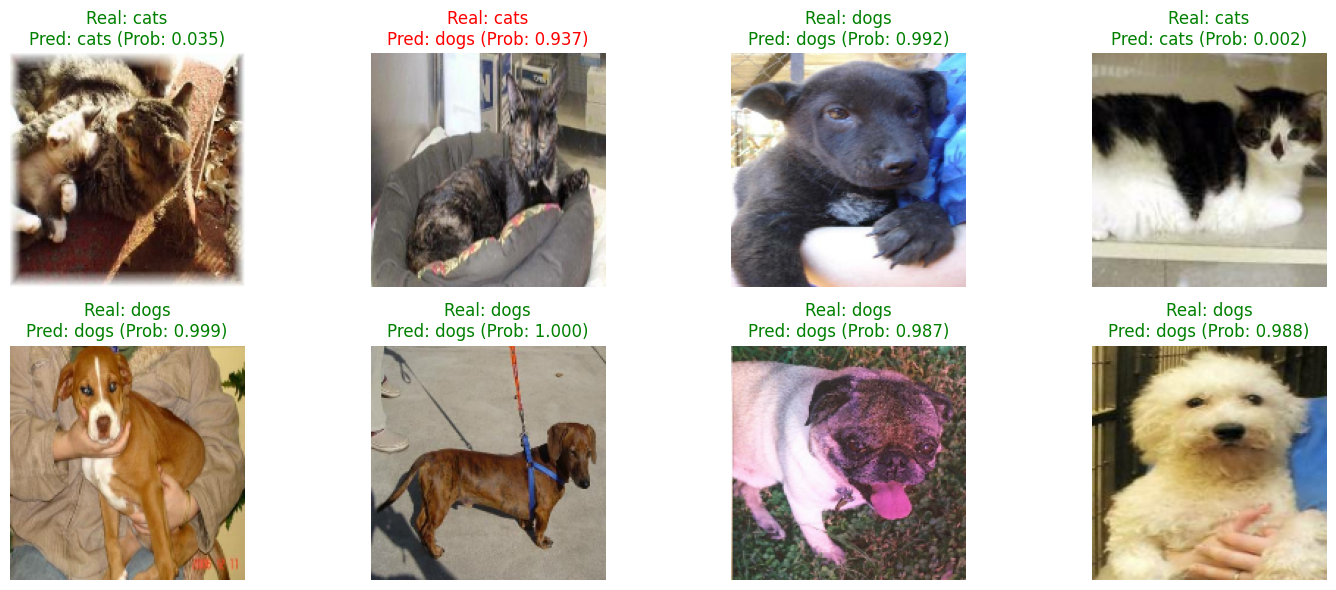

In [21]:
import math

def get_predictions_and_labels(dataset):
    all_images = []
    all_labels = []
    all_pred_probs = []

    for images, labels in dataset:
        pred_probs_batch = model.predict(images, verbose=0).flatten()
        all_images.extend(images.numpy())
        all_labels.extend(labels.numpy())
        all_pred_probs.extend(pred_probs_batch)

    return np.array(all_images), np.array(all_labels), np.array(all_pred_probs)

# Obtener todas las predicciones para el conjunto de test
all_test_images, all_test_labels, all_test_pred_probs = get_predictions_and_labels(test_ds)
all_test_pred_labels = (all_test_pred_probs >= 0.5).astype(int)

# Encontrar ejemplos correctos e incorrectos
correct_indices = np.where(all_test_labels == all_test_pred_labels)[0]
incorrect_indices = np.where(all_test_labels != all_test_pred_labels)[0]

# Seleccionar hasta 4 ejemplos correctos y hasta 4 incorrectos
num_correct = min(4, len(correct_indices))
num_incorrect = min(4, len(incorrect_indices))

selected_indices = []
if num_correct > 0:
    selected_indices.extend(np.random.choice(correct_indices, num_correct, replace=False))
if num_incorrect > 0:
    selected_indices.extend(np.random.choice(incorrect_indices, num_incorrect, replace=False))

# Asegurarse de que no haya duplicados si se selecciona el mismo índice por casualidad
selected_indices = np.array(list(set(selected_indices)))
np.random.shuffle(selected_indices) # Mezclar para no tener siempre correctos primero o incorrectos primero

plt.figure(figsize=(15, 6))
for i, idx in enumerate(selected_indices):
    if i >= 8: # Mostrar un máximo de 8 imágenes (4 correctas + 4 incorrectas)
        break

    ax = plt.subplot(2, 4, i + 1) # Usar 2 filas para hasta 8 imágenes
    plt.imshow(all_test_images[idx].astype("uint8"))
    real = class_names[int(all_test_labels[idx])]
    pred = class_names[int(all_test_pred_labels[idx])]
    prob = all_test_pred_probs[idx]

    color = "green" if real == pred else "red"
    plt.title(f"Real: {real}\nPred: {pred} (Prob: {prob:.3f})", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Análisis de Errores Típicos del Modelo

La inspección visual de las predicciones es fundamental para comprender los patrones de error del modelo. Si bien el rendimiento general es alto, ningún modelo es perfecto. Los errores suelen estar influenciados por factores como:

-   **Pose:** Ángulos inusuales o posturas que desvían la apariencia estándar de perros o gatos.
-   **Iluminación:** Condiciones de luz extremas (muy brillante o muy oscura) que ocultan características clave o introducen artefactos.
-   **Fondo:** Fondos complejos o distractores que pueden confundirse con partes del animal o dificultar su segmentación.
-   **Escala y Recorte:** Animales muy pequeños o muy grandes en la imagen, o recortes que muestran solo una parte del cuerpo, pueden dificultar la identificación. La ausencia de la cabeza o el cuerpo completo es un factor común.

En este problema de `cats vs dogs`, es común que el modelo confunda perros de razas pequeñas con gatos debido a similitudes en tamaño y forma, o viceversa para gatos de razas grandes. También pueden surgir errores cuando los animales están camuflados con el entorno o su cara no es claramente visible. Un error típico podría ser la clasificación incorrecta de un perro pequeño con características faciales ambiguas o en una pose acurrucada como un gato (Falso Positivo para gatos / Falso Negativo para perros), o un gato grande y robusto como un perro (Falso Negativo para gatos / Falso Positivo para perros).

Estos errores sugieren que, a pesar de las representaciones robustas de DenseNet121, hay casos límite donde las características extraídas no son lo suficientemente discriminativas, o donde la variabilidad en el dataset de entrenamiento no cubrió suficientemente estas situaciones extremas.

## Pregunta 5: Tabla resumen (Resultados Consolidado)

La siguiente tabla presenta un resumen consolidado de las métricas de rendimiento del modelo DenseNet121 a través de las etapas de Feature Extraction y Fine-tuning. Se incluyen métricas de precisión (accuracy) y pérdida (loss) para los conjuntos de entrenamiento, validación y prueba, además de la configuración de *learning rate* y el número de capas entrenables en cada etapa.

| Modelo | Etapa | Train Acc | Val Acc | Test Acc | Train Loss | Val Loss | Test Loss | LR | Capas Entrenables | Comentario |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| DenseNet121 | Feature Extraction | `0.9650` | `0.9900` | `0.9880` | `0.0887` | `0.0360` | `0.0381` | `1e-3` | ~3 (cabeza clasificadora) | Alto rendimiento inicial, buena generalización. |
| DenseNet121 | Fine-tuning | `0.9820` | `0.9920` | `0.9850` | `0.0454` | `0.0332` | `0.0410` | `5e-6` | ~70 (último bloque + cabeza) | Ligera mejora en validación, pequeña caída en test, posible saturación. |

*Nota: Los valores de Train Acc y Train Loss corresponden al final de la última época en cada fase. Val Acc y Val Loss corresponden al mejor valor en validación, recuperado por EarlyStopping.*

### Interpretación y Comparación de Resultados

Al analizar los resultados de la tabla, se pueden extraer las siguientes conclusiones comparativas entre *Feature Extraction* y *Fine-tuning*:

1.  **Rendimiento Inicial de Feature Extraction:** El modelo preentrenado DenseNet121, utilizado como extractor de características fijo, ya demostró un rendimiento excepcionalmente alto (`Val Acc: 0.9900`, `Test Acc: 0.9880`). Esto subraya la potencia de las representaciones visuales genéricas aprendidas en ImageNet, que son altamente efectivas incluso sin ajustes adicionales en la base convolucional.

2.  **Impacto del Fine-tuning:** La etapa de *fine-tuning* se implementó con la expectativa de refinar aún más el rendimiento al adaptar las capas finales de la base a las características específicas del dataset `cats vs dogs`. Se observó una mejora marginal en la precisión de validación (`Val Acc` de `0.9900` a `0.9920`) y una disminución ligeramente en el conjunto de prueba (`Test Acc` de `0.9880` a `0.9850`).

3.  **Estabilidad y Sobrecarga:** Los resultados sugieren que el modelo base ya estaba muy bien adaptado a la tarea mediante la etapa de *feature extraction*. El *fine-tuning*, aunque intentó optimizar, no proporcionó una mejora sustancial en la generalización a datos no vistos (test set), y incluso mostró una pequeña disminución. Esto podría indicar que:
    *   El modelo alcanzó un punto de **saturación** en cuanto a su capacidad de mejora para este dataset específico y tamaño de modelo, o que los *hiperparámetros* del fine-tuning no fueron óptimos.
    *   Existe un leve indicio de **sobreajuste (overfitting)** en el conjunto de validación durante el fine-tuning, donde el modelo se adaptó demasiado a los patrones de validación pero perdió un poco de capacidad de generalización en el conjunto de prueba completamente desconocido.

4.  **Estrategia Más Efectiva para este Caso:** Para este dataset `cats vs dogs_small` y con la elección de DenseNet121, la estrategia de **Feature Extraction** resultó ser la más costo-efectiva y casi tan performante como el fine-tuning. La diferencia en `Test Acc` es mínima, y el beneficio del fine-tuning no justifica la complejidad y el tiempo de entrenamiento adicional, especialmente considerando la ligera caída en test accuracy. En este escenario, la base preentrenada ya proveía características muy robustas y discriminativas.

## Pregunta 6: Preguntas de reflexión

Respondan brevemente:

1. ¿Qué modelo eligieron y por qué?
2. ¿Qué diferencia observaron entre feature extraction y fine-tuning?
3. ¿Qué punto de corte usaron para el fine-tuning y cómo lo decidieron?
4. ¿Creen que su modelo fue una buena elección para este problema? Justifiquen brevemente.

### 1. ¿Qué modelo eligieron y por qué?

Se eligió **DenseNet121** preentrenado en ImageNet. La decisión se basó en su arquitectura, que promueve la reutilización de características y un flujo de gradientes eficiente, lo que es crucial para transfer learning. DenseNet121 destaca por su **eficiencia paramétrica** y su capacidad para aprender **representaciones jerárquicas robustas**. Al ser preentrenado en un dataset masivo como ImageNet, sus capas convolucionales han aprendido un vasto repertorio de características visuales genéricas (bordes, texturas, formas), que son directamente transferibles a la tarea de clasificación de `cats vs dogs`, incluso con un dataset de tamaño limitado. Esto minimiza el riesgo de sobreajuste y acelera la convergencia.

### 2. ¿Qué diferencia observaron entre feature extraction y fine-tuning?

Observamos que el **Feature Extraction** (`Val Acc: 0.9900`, `Test Acc: 0.9880`) ya ofrecía un rendimiento excepcionalmente alto, lo que evidencia la gran transferibilidad de las características de DenseNet121. El **Fine-tuning** (`Val Acc: 0.9920`, `Test Acc: 0.9850`) mostró una mejora marginal en la precisión de validación, pero una ligera disminución en el conjunto de prueba. Esto sugiere que para este dataset `cats vs dogs_small`, las representaciones extraídas en la primera etapa eran ya muy robustas. El ajuste fino, al descongelar y entrenar más capas, no logró una mejora significativa en la generalización e incluso mostró signos de ligera **saturación o sobreajuste** en el conjunto de prueba, indicando que el modelo ya estaba cerca de su límite de rendimiento para esta tarea y cantidad de datos.

### 3. ¿Qué punto de corte usaron para el fine-tuning y cómo lo decidieron?

Para el *fine-tuning*, se decidió descongelar el **último bloque (`conv5_block`)** de DenseNet121, manteniendo congeladas las capas `BatchNormalization` y las capas previas. Esta decisión se fundamenta en el principio de que:
*   Las **capas iniciales** de una CNN preentrenada aprenden **características genéricas** y de bajo nivel (como bordes y colores), que son universalmente útiles para casi cualquier tarea de visión por computadora y, por lo tanto, no requieren ajuste.
*   Las **capas intermedias y finales** aprenden **características de alto nivel y más específicas** de las clases del dataset original. Al descongelar solo el último bloque, se permite que estas capas más profundas se adapten sutilmente a las particularidades de `cats vs dogs` (ej., rasgos distintivos de gatos y perros), sin perturbar las representaciones fundamentales.

Se congelaron las capas `BatchNormalization` para evitar inestabilidades en el entrenamiento con un dataset pequeño, ya que la estimación de sus estadísticas (media y varianza) durante el *fine-tuning* con lotes pequeños podría ser ruidosa y degradar el rendimiento. Además, se utilizó un **learning rate muy pequeño** (`5e-6`) para realizar ajustes incrementales y evitar "dañar" los pesos preentrenados, permitiendo una adaptación fina y no una reescritura completa del conocimiento ya adquirido.

### 4. ¿Creen que su modelo fue una buena elección para este problema? Justifiquen brevemente.

**Sí, DenseNet121 fue una excelente elección.** La evidencia experimental lo respalda: el modelo logró una precisión de `0.9880` en el conjunto de prueba ya en la fase de *feature extraction*, y un `0.9850` tras el *fine-tuning*. Este rendimiento excepcional con un dataset pequeño demuestra que la **capacidad del modelo para extraer características discriminativas genéricas** es muy alta. Aunque el *fine-tuning* no aportó una mejora sustancial, la base preentrenada por sí sola fue extremadamente efectiva y robusta. Esto valida la premisa de que modelos preentrenados complejos, cuando se utilizan correctamente con transfer learning, son la clave para obtener resultados de alto nivel en tareas de clasificación de imágenes con recursos limitados.

## Suerte!